**Apartado 1**

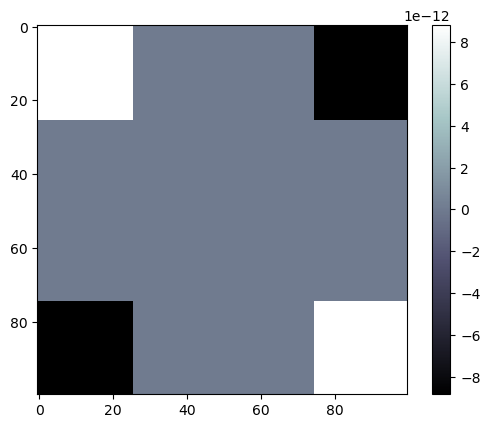

In [1]:
import numpy as np
import matplotlib.pyplot as plt

L=1
a=1/100
N=int(L/a)

p0=8.85e-12
eps0=8.85e-12

# Hacemos máscara

P2 = np.zeros((N,N), float)
P2[0:26,0:26]=p0
P2[75:, 0:26]=-p0
P2[0:26,75:]=-p0
P2[75:,75:]=p0

plt.imshow(P2, cmap="bone")
plt.colorbar()
plt.show()

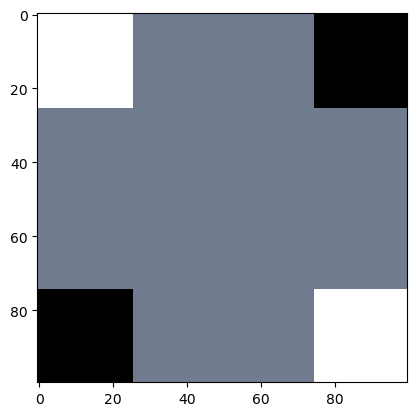

In [2]:
P3 = np.zeros((N,N,N))
P3[:26,:,:]=P2

P3[75:,:,:]=-1*P2

plt.imshow(P3[0,:,:], cmap="bone")
plt.show()

In [3]:
# Resolvemos ec. de Poisson por Jacobi

Psi = np.zeros_like(P3) # ya me cumple conds. de contorno (extremos conectados a tierra)

err = 1.0
tol = 5e-6

while err > tol:
    Psi0=Psi.copy()
    Psi[1:N-1,1:N-1,1:N-1]=1/6*(Psi[2:N,1:N-1,1:N-1]+Psi[0:N-2,1:N-1,1:N-1]+Psi[1:N-1,2:N,1:N-1]+Psi[1:N-1,0:N-2,1:N-1]+Psi[1:N-1,1:N-1,2:N]+Psi[1:N-1,1:N-1,0:N-2]+P3[1:N-1,1:N-1,1:N-1]*a**2/eps0)
    err = np.max(np.abs(Psi-Psi0))

**Apartado 2**

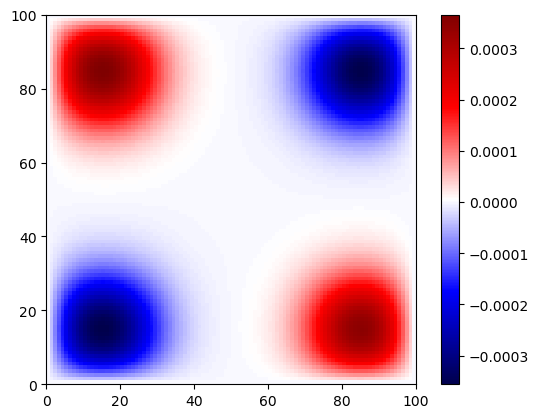

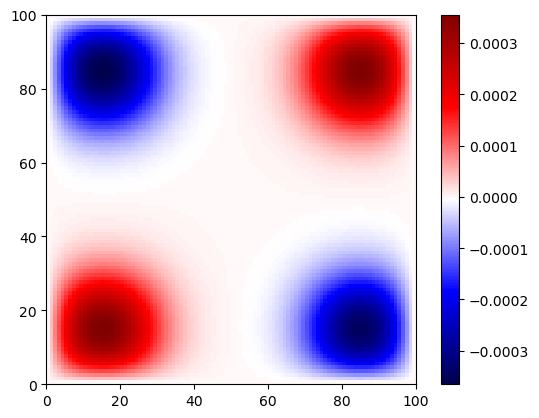

In [4]:
plt.imshow(Psi[:,35,:], extent=[0,100,0,100], cmap="seismic")
plt.colorbar()
plt.show()
plt.imshow(Psi[:,65,:], extent=[0,100,0,100], cmap="seismic")
plt.colorbar()
plt.show()

**Apartado 3**

In [5]:
def make_mask(t):
    p=p0*np.cos(2*np.pi*t)
    P2 = np.zeros((N,N), float)
    P2[0:26,0:26]=p
    P2[75:, 0:26]=-p
    P2[0:26,75:]=-p
    P2[75:,75:]=p
    
    P3 = np.zeros((N,N,N))
    P3[:26,:,:]=P2

    P3[75:,:,:]=-1*P2
    
    return P3

In [6]:
tp = np.linspace(0,1,21)

Psi = np.zeros_like(P3) # cond. inicial
Psis = []

tol = 5e-6

for t in tp:
    print(t)
    P3 = make_mask(t)

    err = 1.0

    while err > tol:
        Psi0=Psi.copy()
        Psi[1:N-1,1:N-1,1:N-1]=1/6*(Psi[2:N,1:N-1,1:N-1]+Psi[0:N-2,1:N-1,1:N-1]+Psi[1:N-1,2:N,1:N-1]+Psi[1:N-1,0:N-2,1:N-1]+Psi[1:N-1,1:N-1,2:N]+Psi[1:N-1,1:N-1,0:N-2]+P3[1:N-1,1:N-1,1:N-1]*a**2/eps0)
        err = np.max(np.abs(Psi-Psi0))
    Psis.append(Psi.copy())

0.0
0.05
0.1
0.15000000000000002
0.2
0.25
0.30000000000000004
0.35000000000000003
0.4
0.45
0.5
0.55
0.6000000000000001
0.65
0.7000000000000001
0.75
0.8
0.8500000000000001
0.9
0.9500000000000001
1.0


**Apartado 4**

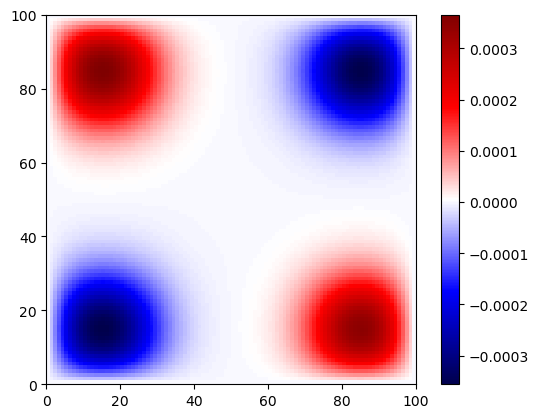

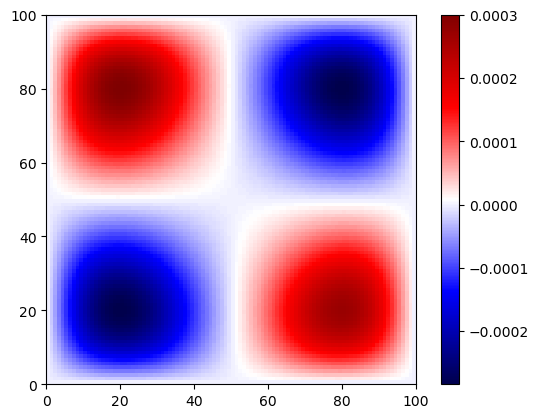

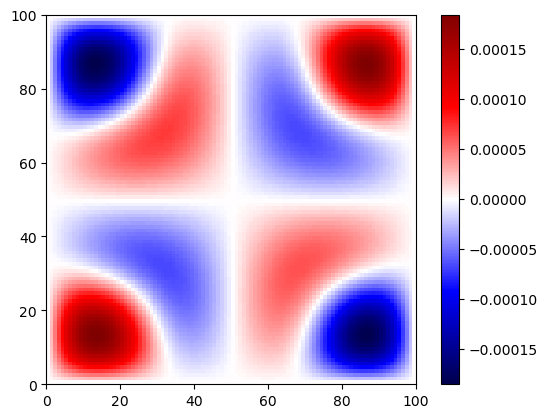

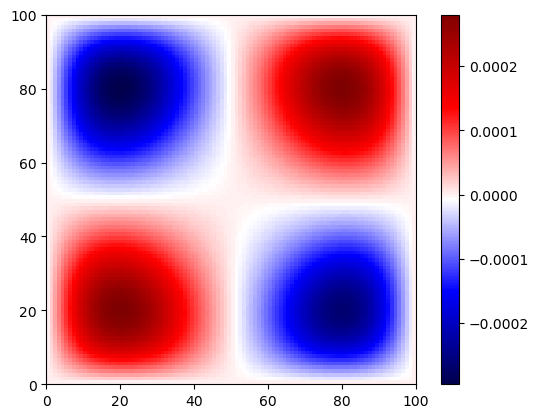

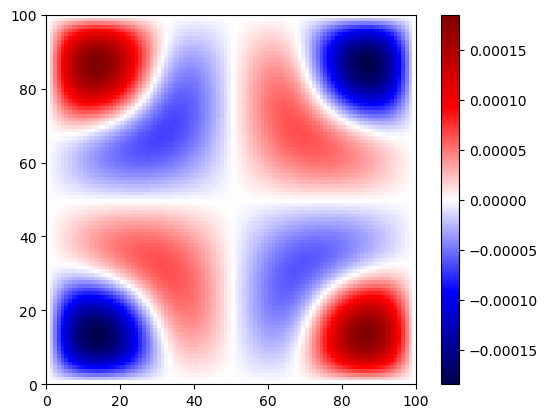

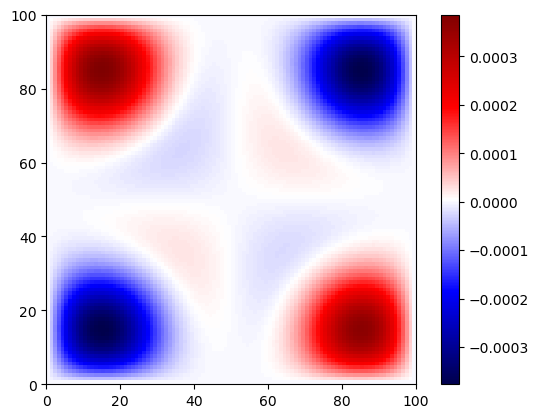

In [7]:
ind = [0,6,8,16,18,-1]

for i in ind:
    plt.imshow(Psis[i][:,35,:], cmap="seismic", extent=[0,100,0,100])
    plt.colorbar()
    plt.show()

**Apartado 5**

In [8]:
def grad_pts(V, a): # EN NEGATIVO, PREPARADO PARA E
    grad_x=np.empty_like(V)
    grad_y=np.empty_like(V)
    grad_z=np.empty_like(V)
    
    grad_x[0, :, :] = (V[1, :, :]-V[0, :, :])/a
    grad_x[-1, :, :] = (V[-2, :, :]-V[-1, :, :])/a
    grad_x[1:-1, :, :] = (V[2:, :, :]-V[0:-2, :, :])/(2*a)
    
    grad_y[:, 0, :] = (V[:,1, :]-V[:,0, :])/a
    grad_y[:, -1, :] = (V[:,-2, :]-V[:,-1, :])/a
    grad_y[:, 1:-1, :] = (V[:, 2:, :]-V[:,0:-2, :])/(2*a)
    
    grad_z[:, :,0] = (V[:, :,1]-V[:, :,0])/a
    grad_z[:, :,-1] = (V[:, :,-2]-V[:, :,-1])/a
    grad_z[:, :, 1:-1] = (V[:, :, 2:]-V[:, :, 0:-2])/(2*a)
    
    return (-1*grad_x, -1*grad_y, -1*grad_z)

In [9]:
Es = []

for i in ind:
    Es.append(grad_pts(Psis[i], a))

**Apartado 6**

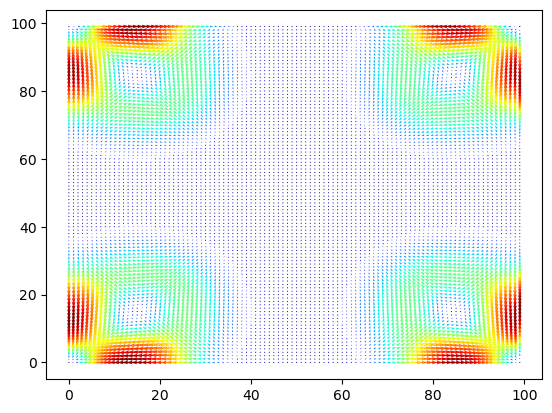

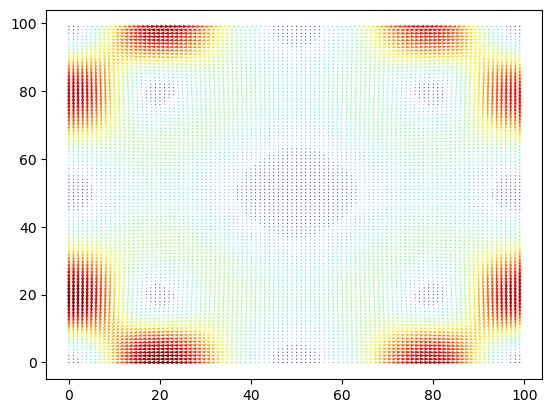

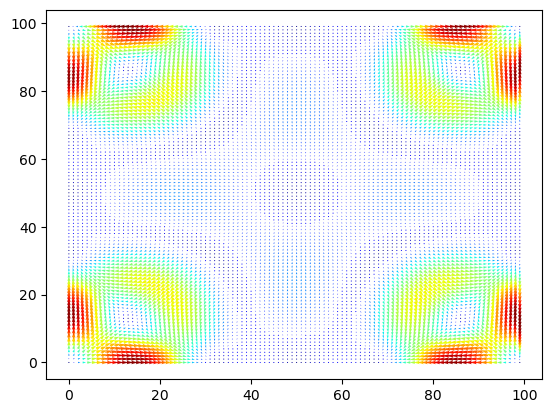

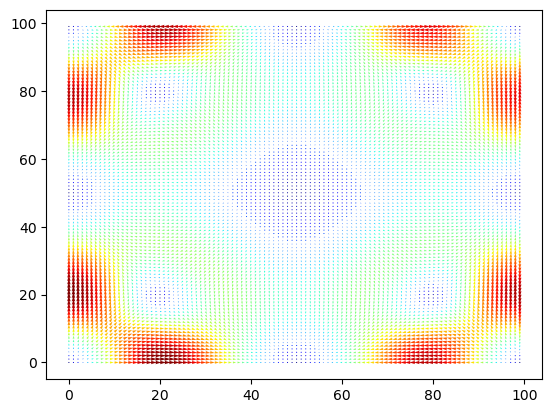

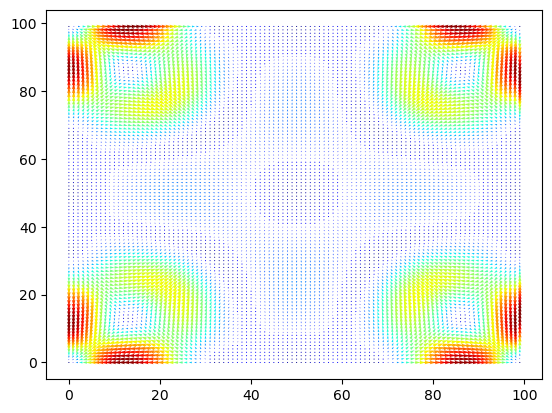

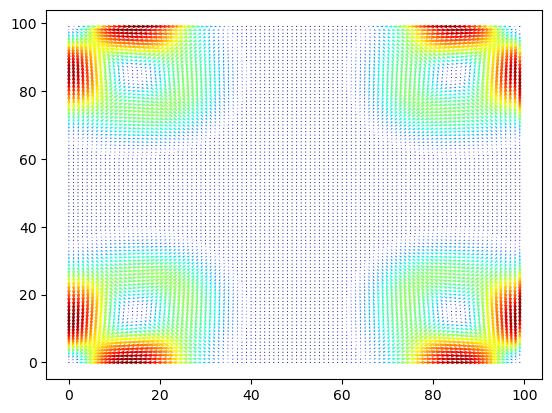

In [10]:
for i in range(len(Es)):
    Ex, Ez = Es[i][0][:,35,:], Es[i][2][:,35,:]
    plt.quiver(Ex, Ez, np.sqrt(Ex**2+Ez**2), cmap="jet")
    plt.show()

**Apartado 7**

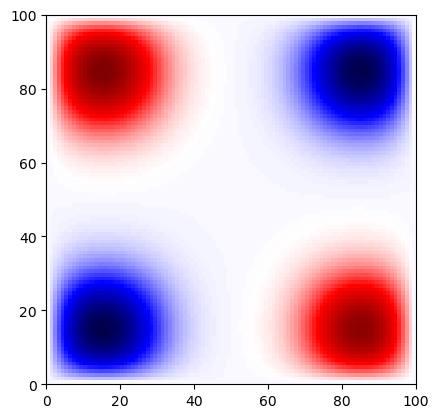

In [11]:
from matplotlib.animation import FuncAnimation
from IPython.core.display import HTML

fig, ax = plt.subplots()

def animacion(frames):
    ax.clear()
    ax.imshow(Psis[frames][:,35,:], cmap="seismic", extent=[0,100,0,100])
    
anim = FuncAnimation(fig, animacion, frames=21, interval=200)
HTML(anim.to_jshtml())